# Module 2: Deep Agents — Text-to-SQL

> Part of the **Modular Workshops** series. Standalone, ~45 min.

Deep Agents = `create_agent()` + a pre-built middleware stack for filesystem access, subagents, and context management. We'll build up from a bare agent to a text-to-SQL analyst that moves through one dependable workflow:

**business question → schema discovery → checked SQL → approved execution → grounded answer**

Along the way we'll cover:

- The harness and built-in tools
- SQL database tools over a bundled SQLite database
- Subagents and context isolation
- Backends and persistent business context
- Middleware for policy and audit
- Human approval before SQL execution
- AGENTS.md and Skills for repeatable SQL workflows


## Setup


In [20]:
import sys
import warnings
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "utils").is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Keep two known upstream serialization/deprecation notices out of workshop output.
warnings.filterwarnings("ignore", message=r"`langchain-community` is being sunset.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=r"(?s)Pydantic serializer warnings:.*Unexpected field `_serialized`", category=UserWarning, module=r"pydantic\.main")

from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_community.utilities import SQLDatabase
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command
from langsmith import uuid7

from utils.models import model
from utils.utils import get_engine_for_chinook_db

# The bundled Chinook fixture is opened read-only by the helper.
chinook_engine = get_engine_for_chinook_db()
database = SQLDatabase(chinook_engine, sample_rows_in_table_info=2)
sql_tools = SQLDatabaseToolkit(db=database, llm=model).get_tools()

# Start each run with a clean long-term memory store (section 1.4 recreates it).
for memory_file in project_root.glob("deep_agents_memory.db*"):
    memory_file.unlink()

print(f"Ready: {database.dialect} database, {len(database.get_usable_table_names())} tables, {len(sql_tools)} custom tools")


Ready: sqlite database, 11 tables, 4 custom tools


---
# Part 1: Deep Agents

Deep Agents = `create_agent()` + a pre-built middleware stack for filesystem access, subagents, and context management.

We'll keep adding one capability at a time until the agent can answer a business question from a SQL database with reviewable, grounded work.


## 1.1 Your First Deep Agent

`create_deep_agent()` gives you a filesystem and context management out of the box—no custom tools required.

<img src="../images/deepAgentsDiag.png" style="width: auto; max-height: 420px; border-radius: 8px;">

### What you get for free:

- **Filesystem Tools** — `ls`, `read_file`, `write_file`, `edit_file`, `delete`, `glob`, `grep`
- **Subagent Delegation** — `task()` for isolated work when subagents are configured
- **Large Tool Result Eviction** — Automatically offloads tool results >20k tokens to the filesystem
- **Conversation Summarization** — Compresses history when approaching context capacity
- **Dangling Tool Call Patching** — Repairs message history after interrupted tool calls

Task planning with `write_todos` can be added when a workflow needs it; our SQL workflow stays explicit and compact in this module.


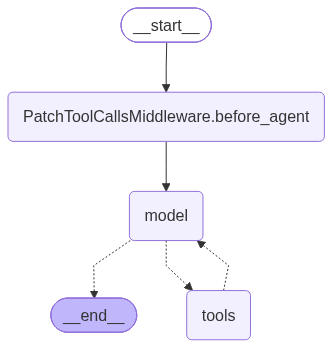

In [21]:
from deepagents import create_deep_agent

agent = create_deep_agent(
    model=model,
    system_prompt="You are a careful data analysis assistant.",
    checkpointer=MemorySaver(),
)
agent


In [22]:
# The agent can use its virtual filesystem before we add custom tools.
config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke(
    {"messages": [{"role": "user", "content": "Write a short plan for answering 'Which countries generate the most revenue?' to /analysis_plan.md, then read it back."}]},
    config=config,
)

print(result["messages"][-1].text)


Written and read back `/analysis_plan.md`:

```markdown
# Analysis plan

1. Identify the revenue measure, time period, and source data.
2. Aggregate revenue by country, validating currency and handling missing or duplicate records.
3. Rank countries by total revenue and report the top countries with amounts and the period covered.
4. Note assumptions, data limitations, and whether the comparison reflects gross or net revenue.
```


In [23]:
# Helper: print the virtual filesystem from a deep agent result.
def print_files(result, header="VIRTUAL FILESYSTEM (in-memory, not on disk!)"):
    files = result.get("files") or {}
    if not files:
        print("(no files in state)")
        return
    print("=" * 50)
    print(header)
    print("=" * 50)
    for path, file_data in files.items():
        print(f"\n  Path: {path!r}")
        print("  " + "-" * 38)
        content = file_data
        if isinstance(file_data, dict) and "content" in file_data:
            content = file_data["content"]
        if isinstance(content, list):
            content = "\n".join(content)
        for line in str(content).split("\n"):
            print(f"  | {line}")

print_files(result)


VIRTUAL FILESYSTEM (in-memory, not on disk!)

  Path: '/analysis_plan.md'
  --------------------------------------
  | # Analysis plan
  | 
  | 1. Identify the revenue measure, time period, and source data.
  | 2. Aggregate revenue by country, validating currency and handling missing or duplicate records.
  | 3. Rank countries by total revenue and report the top countries with amounts and the period covered.
  | 4. Note assumptions, data limitations, and whether the comparison reflects gross or net revenue.
  | 


### Filesystem persistence within a thread

By default, `create_deep_agent()` uses **StateBackend**—files are stored in agent state and persist within a thread through the checkpointer, but disappear when you start a new thread.

| Backend | Storage | Persistence | Use Case |
|---------|---------|-------------|----------|
| **StateBackend** | In-memory agent state | Single thread | Query plans and intermediate analysis |
| **FilesystemBackend** | Local disk | Permanent | Direct file access (use with caution) |
| **StoreBackend** | LangGraph Store | Cross-thread | Business definitions and preferences |
| **CompositeBackend** | Routes to other backends | Mixed | Selective persistence |


In [24]:
# Same thread—the analysis plan persists through the checkpointer.
result = agent.invoke({
    "messages": [{"role": "user", "content": "Read /analysis_plan.md"}]
}, config=config)

print("Same thread:\n\n", result["messages"][-1].text)


Same thread:

 # Analysis plan

1. Identify the revenue measure, time period, and source data.
2. Aggregate revenue by country, validating currency and handling missing or duplicate records.
3. Rank countries by total revenue and report the top countries with amounts and the period covered.
4. Note assumptions, data limitations, and whether the comparison reflects gross or net revenue.


In [25]:
# New thread—StateBackend is ephemeral, so the file is gone.
new_config = {"configurable": {"thread_id": str(uuid7())}}

result = agent.invoke({
    "messages": [{"role": "user", "content": "List all files with ls /"}]
}, config=new_config)

print("New thread:", result["messages"][-1].text)


New thread: No files found in `/`.


### Key Takeaway

- `create_deep_agent()` provides a working harness before domain tools are added
- Virtual files are useful for plans and intermediate analysis
- `StateBackend` persists within a thread but is ephemeral across threads
- Section 1.4 routes selected files to persistent storage


## 1.2 Custom Tools

Deep Agents can use any domain-specific tools passed through `tools=`. For this text-to-SQL agent, `SQLDatabaseToolkit` supplies four custom tools:

1. `sql_db_list_tables`
2. `sql_db_schema`
3. `sql_db_query_checker`
4. `sql_db_query`

Passing them to `create_deep_agent()` gives the agent a simple workflow: **list → inspect → check → execute**.


In [26]:
SQL_SYSTEM_PROMPT = '''You are a careful text-to-SQL analyst working with a SQLite database.

For every database question:
1. List tables and inspect the relevant schemas.
2. Write a SQLite SELECT query.
3. Check it with sql_db_query_checker before executing it.
4. If it fails, revise, check, and retry.

Rules:
- Never use write operations or SELECT *.
- Limit non-aggregate results to 5 rows unless the user requests otherwise.
- Base the final answer only on query results and include the SQL that produced it.
'''

agent = create_deep_agent(
    model=model,
    tools=sql_tools,
    system_prompt=SQL_SYSTEM_PROMPT,
    checkpointer=MemorySaver(),
)

config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke(
    {"messages": [{"role": "user", "content": "How many customers are from Canada? Save the SQL and answer to /analysis.md."}]},
    config=config,
)

print("Agent reply:", result["messages"][-1].text)


Agent reply: 8 customers are from Canada. Saved the SQL and answer to `/analysis.md`.


In [27]:
# The database result grounded the answer; the filesystem holds the artifact.
print_files(result, header="TEXT-TO-SQL ANALYSIS ARTIFACT")


TEXT-TO-SQL ANALYSIS ARTIFACT

  Path: '/analysis.md'
  --------------------------------------
  | # Analysis
  | 
  | **Question:** How many customers are from Canada?
  | 
  | **SQL:**
  | ```sql
  | SELECT COUNT(*) AS customer_count
  | FROM Customer
  | WHERE Country = 'Canada';
  | ```
  | 
  | **Answer:** 8 customers are from Canada.
  | 


## 1.3 Subagents: Isolated Delegation

Subagents run in a separate context. The main agent delegates a database question via `task()` and receives only the final result, keeping schema details and intermediate SQL work out of the main context.

<img src="../images/deepAgentSubagents.png" style="width: auto; max-height: 380px; border-radius: 8px;">


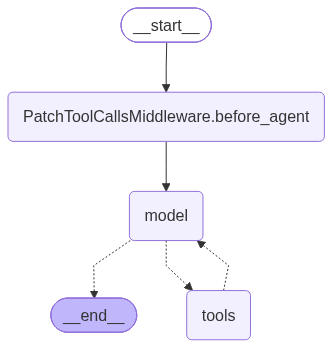

In [28]:
sql_subagent = {
    "name": "sql-analyst",
    "description": "Delegate database questions that require schema exploration or SQL execution.",
    "system_prompt": SQL_SYSTEM_PROMPT + "\nReturn the checked SQL, query results, and a concise answer.",
    "tools": sql_tools,
}

agent = create_deep_agent(
    model=model,
    system_prompt=(
        "You coordinate data analysis. Delegate every database question to the "
        "sql-analyst with task(), then present its grounded answer."
    ),
    subagents=[sql_subagent],
    checkpointer=MemorySaver(),
)
agent


In [29]:
config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke(
    {"messages": [{"role": "user", "content": "Which five artists generated the most sales revenue?"}]},
    config=config,
)
print(result["messages"][-1].text)


The five artists with the highest sales revenue are:

| Rank | Artist | Revenue |
|---:|---|---:|
| 1 | Iron Maiden | $138.60 |
| 2 | U2 | $105.93 |
| 3 | Metallica | $90.09 |
| 4 | Led Zeppelin | $86.13 |
| 5 | Lost | $81.59 |

Revenue was calculated as the sum of `InvoiceLine.Quantity × InvoiceLine.UnitPrice`.


## 1.4 Backends & Memory

By default, files live in ephemeral state (`StateBackend`). Use `CompositeBackend` to route selected paths—for example, `/memories/` to persistent `StoreBackend` while everything else stays ephemeral.

`StoreBackend` is useful for business context that should survive across conversations: metric definitions, approved table mappings, or user preferences. Here it is backed by a separate local SQLite file; it is not the Chinook analytics database.

`StoreBackend` scopes reads and writes by `namespace`, which can isolate memory per user, assistant, or tenant. This workshop uses one shared namespace for simplicity.


In [30]:
import sqlite3
from deepagents.backends import StateBackend, StoreBackend, CompositeBackend
from langgraph.store.sqlite import SqliteStore

MEMORY_DB = project_root / "deep_agents_memory.db"

def open_memory_store(path=MEMORY_DB):
    '''Open (or create) a persistent SQLite-backed long-term memory store.'''
    connection = sqlite3.connect(path, check_same_thread=False, isolation_level=None)
    store = SqliteStore(connection)
    store.setup()
    return store

store = open_memory_store()

backend = CompositeBackend(
    default=StateBackend(),
    routes={
        "/memories/": StoreBackend(
            store=store,
            namespace=lambda runtime: ("memories", "shared"),
        ),
    },
)

agent = create_deep_agent(
    model=model,
    tools=sql_tools,
    system_prompt=SQL_SYSTEM_PROMPT + "\nCheck /memories/ before querying and save definitions the user asks you to remember.",
    backend=backend,
    store=store,
    checkpointer=MemorySaver(),
)

# Thread 1: save a business definition without querying the database.
config1 = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke(
    {"messages": [{"role": "user", "content": "Remember that sales revenue is SUM(InvoiceLine.UnitPrice * InvoiceLine.Quantity). Save it to /memories/metric_definitions.md. Do not query yet."}]},
    config=config1,
)
print("Thread 1:", result["messages"][-1].text)


Thread 1: Saved to `/memories/metric_definitions.md`:

**Sales revenue**: `SUM(InvoiceLine.UnitPrice * InvoiceLine.Quantity)`


In [31]:
# Thread 2: a new conversation reuses the persisted revenue definition.
config2 = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "Using our saved definition, which five artists generated the most sales revenue?",
    }]
}, config=config2)
print("Thread 2:", result["messages"][-1].text)


Thread 2: Using the saved definition—`SUM(InvoiceLine.UnitPrice * InvoiceLine.Quantity)`—the five artists with the highest sales revenue are:

1. **Iron Maiden** — $138.60  
2. **U2** — $105.93  
3. **Metallica** — $90.09  
4. **Led Zeppelin** — $86.13  
5. **Lost** — $81.59  

```sql
SELECT ar.Name AS artist, SUM(il.UnitPrice * il.Quantity) AS sales_revenue
FROM InvoiceLine AS il
JOIN Track AS t ON t.TrackId = il.TrackId
JOIN Album AS al ON al.AlbumId = t.AlbumId
JOIN Artist AS ar ON ar.ArtistId = al.ArtistId
GROUP BY ar.ArtistId, ar.Name
ORDER BY sales_revenue DESC
LIMIT 5;
```


## 1.5 Middleware: Pluggable Behavior

Middleware hooks into `wrap_model_call` and `wrap_tool_call`. This lets us apply database-use rules to every model call and record every tool invocation without changing the agent's core logic.

<img src="../images/deepAgentMiddleware.png" style="width: auto; max-height: 380px; border-radius: 8px;">

### Built-in context management

Deep Agents also manages growing context automatically:

- **Offload Large Inputs** — Older file-operation content can be replaced with filesystem references.
- **Offload Large Results** — Tool results over ~20k tokens are written to the backend with a short preview left in context.
- **Conversation Summarization** — Long histories are summarized, with full messages retained under `/conversation_history/`.

These controls matter for database work because schemas and query results can become large. They manage context size; SQL result limits and database permissions remain separate responsibilities.


In [32]:
from datetime import datetime

from langchain.agents.middleware import wrap_model_call, wrap_tool_call
from langchain_core.messages import SystemMessage

audit_log = []

@wrap_model_call
def sql_policy(request, handler):
    '''Inject database-use rules into every model call.'''
    rules = '''## Database Policy
- Use only SELECT queries; the connection is read-only
- Inspect relevant schemas and check every query before execution
- Do not return raw email, phone, address, or other contact fields
- Prefer aggregates and limit non-aggregate results to 5 rows
- Base conclusions only on rows returned by the database'''
    existing = request.system_message
    blocks = list(existing.content_blocks) if existing else []
    blocks.append({"type": "text", "text": f"\n\n{rules}"})
    return handler(request.override(system_message=SystemMessage(content_blocks=blocks)))

@wrap_tool_call
def audit_trail(request, handler):
    '''Record every tool call without storing its arguments or result data.'''
    result = handler(request)
    audit_log.append({
        "tool": request.tool_call["name"],
        "timestamp": datetime.now().isoformat(),
        "status": "success",
    })
    return result

agent_with_middleware = create_deep_agent(
    model=model,
    tools=sql_tools,
    system_prompt=SQL_SYSTEM_PROMPT,
    middleware=[sql_policy, audit_trail],
    checkpointer=MemorySaver(),
)

config = {"configurable": {"thread_id": str(uuid7())}}
result = agent_with_middleware.invoke(
    {"messages": [{"role": "user", "content": "Which five countries generated the most invoice revenue?"}]},
    config=config,
)

print(result["messages"][-1].text)
print(f"\n--- Audit Log ({len(audit_log)} entries) ---")
for entry in audit_log:
    print(f"  {entry['timestamp']}  {entry['tool']:24s} {entry['status']}")


The five countries with the most invoice revenue are:

1. **USA** — $523.06  
2. **Canada** — $303.96  
3. **France** — $195.10  
4. **Brazil** — $190.10  
5. **Germany** — $156.48  

```sql
SELECT BillingCountry AS country, ROUND(SUM(Total), 2) AS revenue
FROM Invoice
GROUP BY BillingCountry
ORDER BY revenue DESC
LIMIT 5;
```

--- Audit Log (4 entries) ---
  2026-09-14T22:45:43.579683  sql_db_list_tables       success
  2026-09-14T22:45:44.693610  sql_db_schema            success
  2026-09-14T22:45:48.282471  sql_db_query_checker     success
  2026-09-14T22:45:49.363214  sql_db_query             success


## 1.6 HITL: Review SQL Before Execution

Deep Agents supports `interrupt_on`, which can pause a sensitive tool call for approval, editing, or rejection. Here the agent may explore schemas and check SQL autonomously, but it pauses immediately before `sql_db_query` executes.

<img src="../images/deepAgentHITL.png" style="width: auto; max-height: 380px; border-radius: 8px;">

> Query checking and human approval improve reliability, but they are not security boundaries. Production agents still need narrowly scoped, read-only credentials and application-level validation.


In [33]:
agent_with_hitl = create_deep_agent(
    model=model,
    tools=sql_tools,
    system_prompt=SQL_SYSTEM_PROMPT,
    checkpointer=MemorySaver(),
    interrupt_on={
        "sql_db_query": {
            "allowed_decisions": ["approve", "edit", "reject"],
        },
    },
)

config = {"configurable": {"thread_id": str(uuid7())}}
result = agent_with_hitl.invoke({
    "messages": [{
        "role": "user",
        "content": "Which country generated the highest total invoice revenue?",
    }]
}, config=config)

if result.get("__interrupt__"):
    interrupt_info = result["__interrupt__"][0].value
    for action in interrupt_info["action_requests"]:
        print(f"Paused—tool: {action['name']}")
        print("Proposed SQL:", action["args"].get("query"))
    print("\nWaiting for approval...")


Paused—tool: sql_db_query
Proposed SQL: SELECT BillingCountry, SUM(Total) AS total_revenue
FROM Invoice
GROUP BY BillingCountry
ORDER BY total_revenue DESC
LIMIT 5;

Waiting for approval...


In [34]:
# Approve the proposed SQL and continue from the checkpoint.
if result.get("__interrupt__"):
    result = agent_with_hitl.invoke(
        Command(resume={"decisions": [{"type": "approve"}]}),
        config=config,
    )
    print("Approved!")
    print("Agent reply:", result["messages"][-1].text)


Approved!
Agent reply: The **USA** generated the highest total invoice revenue: **$523.06**.

```sql
SELECT BillingCountry, SUM(Total) AS total_revenue
FROM Invoice
GROUP BY BillingCountry
ORDER BY total_revenue DESC
LIMIT 5;
```


## 1.7 AGENTS.md & Skills

`AGENTS.md` moves the agent's stable identity and rules out of a hardcoded prompt. Skills provide focused procedures that load only when the task matches. For text-to-SQL, this is a natural place to encode a schema-first query workflow.


In [35]:
from deepagents.backends.utils import create_file_data

agents_md = '''# Text-to-SQL Analyst

You are a careful analyst working with a read-only SQLite database.

## Workflow
1. List the available tables
2. Inspect only the schemas relevant to the question
3. Write a SELECT query using the query-writing skill
4. Check the query before executing it
5. Answer only from returned rows and include the final SQL

## Rules
- Never execute DDL or DML
- Never use SELECT *
- Limit non-aggregate results to 5 rows unless asked otherwise
- Do not return raw contact information
- For complex questions, delegate schema and query planning when a SQL subagent is available
'''

query_writing_skill = '''---
name: query-writing
description: Write, check, and execute read-only SQL for database questions and analytical reports.
---

# Query Writing

1. Call `sql_db_list_tables`.
2. Call `sql_db_schema` for only the relevant tables.
3. Write a SQLite `SELECT` query with explicit columns and join conditions.
4. Add `LIMIT 5` to non-aggregate results unless the user requested another limit.
5. Call `sql_db_query_checker`.
6. Execute the checked query with `sql_db_query`.
7. If execution fails, revise, check, and retry.
8. Include the executed SQL and a concise result-grounded answer.
'''

agent = create_deep_agent(
    model=model,
    tools=sql_tools,
    memory=["/AGENTS.md"],
    skills=["/skills/"],
    checkpointer=MemorySaver(),
)

config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "Which five genres generated the most sales revenue?",
    }],
    "files": {
        "/AGENTS.md": create_file_data(agents_md),
        "/skills/query-writing/SKILL.md": create_file_data(query_writing_skill),
    },
}, config=config)

print(result["messages"][-1].text)


The five genres with the highest sales revenue were:

1. **Rock** — **$826.65**
2. **Latin** — **$382.14**
3. **Metal** — **$261.36**
4. **Alternative & Punk** — **$241.56**
5. **TV Shows** — **$93.53**

```sql
SELECT g.Name AS genre, SUM(il.UnitPrice * il.Quantity) AS total_revenue
FROM InvoiceLine AS il
JOIN Track AS t ON il.TrackId = t.TrackId
JOIN Genre AS g ON t.GenreId = g.GenreId
GROUP BY g.GenreId, g.Name
ORDER BY total_revenue DESC
LIMIT 5;
```


## 1.8 The Complete Agent

Now we combine the same pieces: SQL tools, isolated query planning, persistent business context, policy and audit middleware, human review before execution, AGENTS.md, and an on-demand query-writing skill.

The notebook remains self-contained. Other workshop modules keep their own purpose-built agents rather than depending on this example.


In [36]:
store = open_memory_store()
audit_log = []

complete_backend = CompositeBackend(
    default=StateBackend(),
    routes={
        "/memories/": StoreBackend(
            store=store,
            namespace=lambda runtime: ("memories", "shared"),
        ),
    },
)

query_planner_subagent = {
    "name": "query-planner",
    "description": "Delegate complex schema exploration and SQL query design.",
    "system_prompt": "List tables, inspect schemas, and return a checked, read-only SQLite SELECT query. Do not execute it or claim results.",
    "tools": [tool for tool in sql_tools if tool.name != "sql_db_query"],
}

complete_agent = create_deep_agent(
    model=model,
    tools=sql_tools,
    subagents=[query_planner_subagent],
    backend=complete_backend,
    store=store,
    middleware=[sql_policy, audit_trail],
    checkpointer=MemorySaver(),
    interrupt_on={
        "sql_db_query": {
            "allowed_decisions": ["approve", "edit", "reject"],
        },
    },
    memory=["/AGENTS.md"],
    skills=["/skills/"],
)

print("Complete text-to-SQL agent ready")


Complete text-to-SQL agent ready


In [37]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": str(uuid7())}}
seed_files = {
    "/AGENTS.md": create_file_data(agents_md),
    "/skills/query-writing/SKILL.md": create_file_data(query_writing_skill),
}

result = complete_agent.invoke({
    "messages": [HumanMessage(content=(
        "Which five artists generated the most sales revenue? "
        "Delegate schema exploration and query planning to the query-planner, "
        "then execute the checked query yourself. Save the final SQL and answer "
        "to /final_analysis.md, and save the revenue definition to "
        "/memories/metric_definitions.md."
    ))],
    "files": seed_files,
}, config=config)

# Approve each proposed read-only SQL query and resume from the checkpoint.
while result.get("__interrupt__"):
    payload = result["__interrupt__"][0].value
    actions = payload.get("action_requests", [])
    for action in actions:
        print(f"HITL pause—reviewing {action['name']}:")
        print(action["args"].get("query", ""))
    result = complete_agent.invoke(
        Command(resume={
            "decisions": [{"type": "approve"} for _ in actions],
        }),
        config=config,
    )

print("\nFinal reply:\n", result["messages"][-1].text[:800])
print()

seed_paths = set(seed_files)
agent_files = {
    path: data
    for path, data in (result.get("files") or {}).items()
    if path not in seed_paths
}
print_files({"files": agent_files}, header="FILES THE AGENT WROTE")

print(f"\nAudit log: {len(audit_log)} tool call(s)")
for entry in audit_log:
    print(f"  {entry['timestamp']}  {entry['tool']:24s} {entry['status']}")


HITL pause—reviewing sql_db_query:
SELECT
    ar.ArtistId,
    ar.Name AS ArtistName,
    ROUND(SUM(il.UnitPrice * il.Quantity), 2) AS Revenue
FROM Artist AS ar
JOIN Album AS al
    ON al.ArtistId = ar.ArtistId
JOIN Track AS t
    ON t.AlbumId = al.AlbumId
JOIN InvoiceLine AS il
    ON il.TrackId = t.TrackId
GROUP BY ar.ArtistId, ar.Name
ORDER BY Revenue DESC, ar.Name ASC
LIMIT 5;

Final reply:
 The five artists generating the most sales revenue are:

1. **Iron Maiden** — $138.60  
2. **U2** — $105.93  
3. **Metallica** — $90.09  
4. **Led Zeppelin** — $86.13  
5. **Lost** — $81.59  

Revenue is defined as `SUM(InvoiceLine.UnitPrice * InvoiceLine.Quantity)` across each artist’s sold tracks.

The final SQL and results were saved to `/final_analysis.md`, and the metric definition was saved to `/memories/metric_definitions.md`.

FILES THE AGENT WROTE

  Path: '/final_analysis.md'
  --------------------------------------
  | # Top Five Artists by Sales Revenue
  | 
  | Sales revenue is def

### Deep Agents Recap

| Feature | Text-to-SQL role | Built-in? |
|---------|------------------|-----------|
| **Harness** | Filesystem and context management | Included by `create_deep_agent()` |
| **Custom tools** | List tables, inspect schemas, check SQL, execute SQL | Passed through `tools=` |
| **Subagents** | Isolated schema exploration and query planning | Configured through `subagents=` |
| **Memory** | Persist metric definitions across threads | Routed to `StoreBackend` |
| **Middleware** | Inject database policy and audit tool calls | Added through `middleware=` |
| **HITL** | Review SQL immediately before execution | Configured with `interrupt_on` |
| **AGENTS.md** | Stable analyst identity and rules | Loaded through `memory=` |
| **Skills** | On-demand schema-first query workflow | Loaded through `skills=` |

We started with a business question and ended with checked, approved SQL and an answer grounded in database rows. The same agent pattern can point at a production warehouse, but production safety comes from least-privilege database access and application controls—not prompts alone.
